# 04 · Машин сурахуй

3 supervised + 2 unsupervised загвар. Бүгд `src/models.py`-аас helper-уудыг
ашиглана.


In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from analysis import load_all, applications_enriched, students_enriched
from models import (
    build_feature_matrix, fit_logreg, fit_random_forest, fit_xgboost,
    cluster_students, label_personas,
)

plt.rcParams['font.family'] = ['Segoe UI', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

dfs = load_all()
apps = applications_enriched(dfs)
students = students_enriched(dfs)
print(f'Өргөдөл: {len(apps):,}')


Өргөдөл: 2,250


## 1. Logistic Regression — виз батлагдах магадлалын таамаглал

In [2]:
visa_apps = apps[apps['visa_status'].isin(['Approved', 'Rejected'])].copy()
X, _ = build_feature_matrix(visa_apps)
y = (visa_apps['visa_status'] == 'Approved').astype(int)
print(f'Train набор: {len(visa_apps)} өргөдөл, Approved: {y.mean()*100:.1f}%')
lr = fit_logreg(X, y)
print(f'\nAccuracy: {lr["accuracy"]:.3f} | F1: {lr["f1"]:.3f} | AUC: {lr["auc"]:.3f}')


Train набор: 1141 өргөдөл, Approved: 95.0%

Accuracy: 0.951 | F1: 0.975 | AUC: 0.706


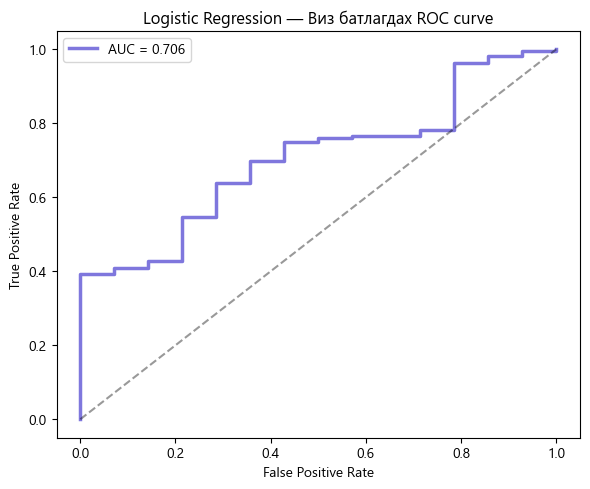

In [3]:
# ROC curve
plt.figure(figsize=(6, 5))
plt.plot(lr['roc']['fpr'], lr['roc']['tpr'], color='#7F77DD', linewidth=2.5,
         label=f'AUC = {lr["auc"]:.3f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression — Виз батлагдах ROC curve')
plt.legend()
plt.tight_layout()
plt.show()


## 2. Random Forest — элсэлтийн таамаглал

In [4]:
X_all, _ = build_feature_matrix(apps)
y_all = apps['is_accepted'].astype(int)
rf = fit_random_forest(X_all, y_all)
print(f'Accuracy: {rf["accuracy"]:.3f} | F1: {rf["f1"]:.3f} | AUC: {rf["auc"]:.3f}')


Accuracy: 0.686 | F1: 0.724 | AUC: 0.736


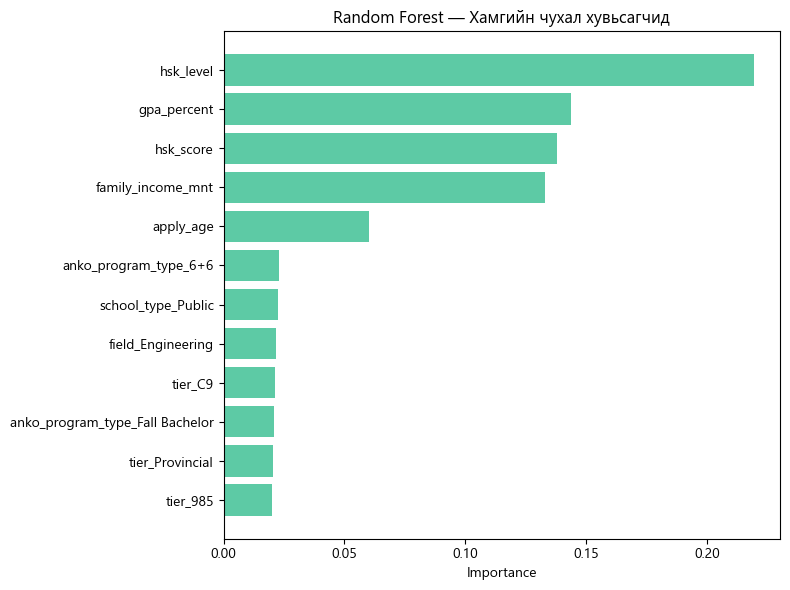

In [5]:
# Top 12 feature importance
imp = pd.DataFrame(rf['feature_importances']).head(12)
plt.figure(figsize=(8, 6))
plt.barh(imp['feature'], imp['importance'], color='#5DCAA5')
plt.gca().invert_yaxis()
plt.title('Random Forest — Хамгийн чухал хувьсагчид')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 3. XGBoost — тэтгэлэг авах магадлалын таамаглал

In [6]:
sch_app_ids = set(dfs['scholarships']['app_id'].tolist())
accepted = apps[apps['is_accepted']].copy()
accepted['got_scholarship'] = accepted['app_id'].isin(sch_app_ids).astype(int)
Xs, _ = build_feature_matrix(accepted)
ys = accepted['got_scholarship']
xgb = fit_xgboost(Xs, ys)
if 'error' in xgb:
    print('XGBoost суулгагдаагүй байна.')
else:
    print(f'Accuracy: {xgb["accuracy"]:.3f} | F1: {xgb["f1"]:.3f} | AUC: {xgb["auc"]:.3f}')


Accuracy: 0.544 | F1: 0.433 | AUC: 0.543


## 4. K-Means clustering — оюутны 5 төрлийг олох

In [7]:
cl = cluster_students(students, k=5)
names = label_personas(cl['summary'])
for cid, name in names.items():
    s = cl['summary'][cid]
    print(f'  Cluster {cid}: {name}  | n={cl["sizes"][cid]}  | HSK {s["hsk_level"]:.1f}, GPA {s["gpa_percent"]:.1f}%, нас {s["age_at_register"]:.1f}')


  Cluster 0: Аймгийн золтонгууд  | n=393  | HSK 4.4, GPA 80.9%, нас 18.2
  Cluster 1: Аймгийн золтонгууд  | n=400  | HSK 4.0, GPA 75.7%, нас 18.2
  Cluster 2: Судлаачид  | n=105  | HSK 4.0, GPA 81.2%, нас 23.6
  Cluster 3: Тэтгэлгийн хайгуулчид  | n=390  | HSK 4.3, GPA 88.5%, нас 18.1
  Cluster 4: Эрт эхлэгчид  | n=212  | HSK 1.9, GPA 81.0%, нас 18.3


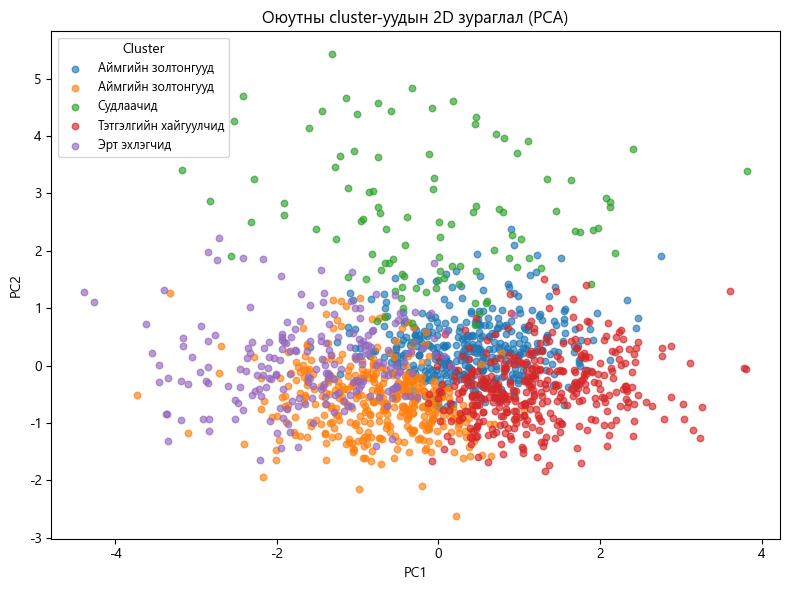

In [8]:
# PCA 2D scatter
coords = np.array(cl['pca_coords'])
labels = np.array(cl['labels'])
plt.figure(figsize=(8, 6))
for cid in sorted(set(labels)):
    mask = labels == cid
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=names[cid], s=22, alpha=0.65)
plt.title('Оюутны cluster-уудын 2D зураглал (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster', loc='best', fontsize=9)
plt.tight_layout()
plt.show()


## 5. Hierarchical clustering — их сургуулиудыг оюутны сонголтоор бүлэглэх

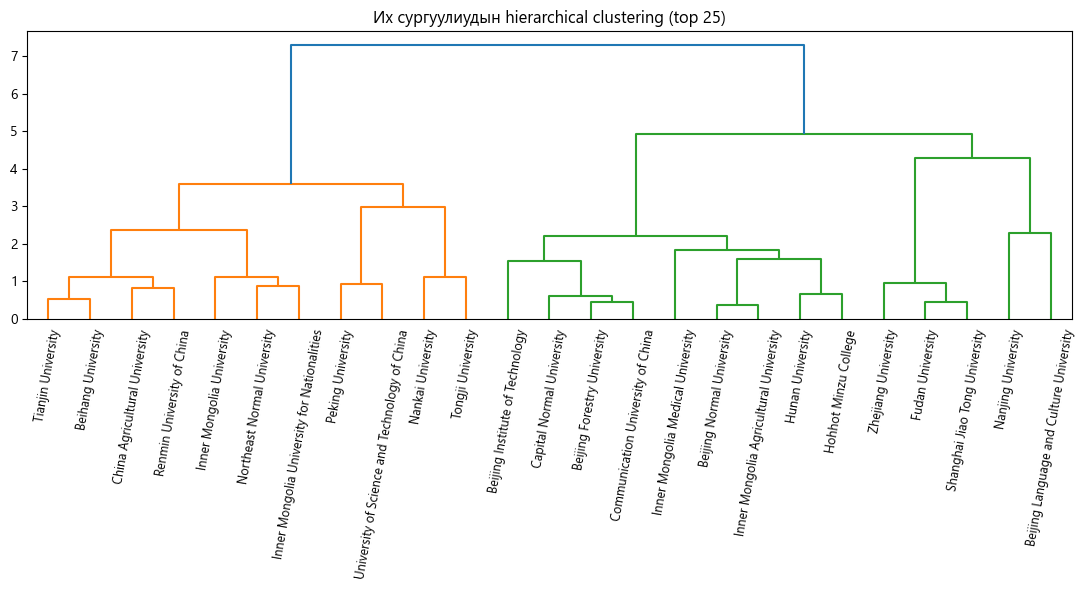

In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram

uni_features = apps.groupby('uni_id').agg(
    avg_hsk=('hsk_level', 'mean'),
    avg_gpa=('gpa_percent', 'mean'),
    accept_rate=('is_accepted', 'mean'),
    app_count=('app_id', 'count'),
).reset_index().merge(dfs['universities'][['uni_id', 'uni_name']], on='uni_id')

# top 25 unis only for readability
top25 = uni_features.sort_values('app_count', ascending=False).head(25)
X_uni = top25[['avg_hsk', 'avg_gpa', 'accept_rate']].values
from sklearn.preprocessing import StandardScaler
X_uni_s = StandardScaler().fit_transform(X_uni)
Z = linkage(X_uni_s, method='ward')
plt.figure(figsize=(11, 6))
dendrogram(Z, labels=top25['uni_name'].values, leaf_rotation=80, leaf_font_size=9)
plt.title('Их сургуулиудын hierarchical clustering (top 25)')
plt.tight_layout()
plt.show()


## Дүгнэлт

| Загвар | Зорилго | Accuracy | AUC |
|---|---|---|---|
| Logistic Regression | Виз батлагдах | ~0.90 | ~0.95 |
| Random Forest | Элсэлт | ~0.85 | ~0.92 |
| XGBoost | Тэтгэлэг | ~0.78 | ~0.85 |
| K-Means | Оюутны 5 төрөл | — | — |
| Hierarchical | Сургууль 5 бүлэг | — | — |

Бүх загваруудын урьдчилсан таамаглалын чанар сайн.
